<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 9: Discrete Fourier Transform (DFT)

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#frequency_content" style="color:black;">From Waveforms to Frequency Content</a></li>
    <li><a href="#background_inner" style="color:#1B5E20;"><strong>Background:</strong> The Geometric Meaning of Inner Products</a></li>
    <li><a href="#signal_inner" style="color:black;">Comparing Signals with Inner Products</a></li>
    <li><a href="#signal_phase" style="color:black;">The Role of Phase</a></li>
    <li><a href="#complex_exponentials" style="color:black;">Comparing Signals with Complex Exponentials</a></li>
    <li><a href="#dft" style="color:black;">Discrete Fourier Transform (DFT)</a></li>
    <li><a href="#background_complexity" style="color:#1B5E20;"><strong>Background:</strong> Background: Computational Efficiency and the Power of Algorithms</a></li>
    <li><a href="#fft" style="color:black;">Fast Fourier Transform (FFT)</a></li>
    <li><a href="#exercise_leakage" style="color:#006064;"><strong>Exercise 1:</strong> Frequency Bins and Spectral Leakage</a></li>
    <li><a href="#exercise_missing_time" style="color:#006064;"><strong>Exercise 2:</strong> Missing Time Localization</a></li>
    <li><a href="#exercise_spectral_modification" style="color:#006064;"><strong>Exercise 3:</strong> Spectral Modification and Reconstruction</a></li>
</ul>

<a id="learn"></a>

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
A waveform shows how a signal changes over time, but it may not clearly reveal the oscillations from which the signal is built. <strong>Fourier analysis</strong> provides another perspective by representing a signal as a weighted superposition of sinusoids. The resulting <strong>frequency representation</strong>, or spectrum, reveals which frequencies occur and how strongly they contribute. In this unit, we study the <strong>discrete Fourier transform</strong> (DFT), which analyzes finite discrete-time signals. Building on complex exponentials and roots of unity from <a href="PCP_07_exp.html">Unit 7</a> and sampled signals from <a href="PCP_08_signal.html">Unit 8</a>, we interpret each Fourier coefficient as an inner product that compares the signal with a particular complex oscillation. We then examine the magnitude and phase of these coefficients, express the DFT as a matrix, reconstruct signals using the inverse DFT, and study the <strong>fast Fourier transform</strong> (FFT), which computes the same result much more efficiently. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Interpret an inner product as a comparison between finite signals.</li>
<li>Explain the DFT as a comparison with sampled complex exponentials.</li>
<li>Relate DFT indices to physical frequencies and interpret positive and negative frequencies.</li>
<li>Interpret the magnitude and phase of Fourier coefficients.</li>
<li>Explain frequency resolution, conjugate symmetry, and spectral leakage.</li>
<li>Construct the DFT matrix and reconstruct a signal using the inverse DFT.</li>
<li>Explain why the FFT is substantially faster than a direct DFT computation.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_leakage">Exercise 1</a>: Explore frequency bins and spectral leakage.</li>
<li><a href="#exercise_missing_time">Exercise 2</a>: Investigate the loss of time localization and its connection to the <a href="https://www.audiolabs-erlangen.de/resources/MIR/FMP/C2/C2_STFT-Basic.html">short-time Fourier transform</a>.</li>
<li><a href="#exercise_spectral_modification">Exercise 3</a>: Modify Fourier coefficients, reconstruct the signal, and examine the audible result.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
The time-domain signal and its frequency-domain representation contain the same information but organize it differently. <strong>The DFT replaces the question “What happens at each moment?” with “Which oscillations are present?”</strong>
</p>

</div>


In [48]:
# --- Core scientific stack ---
import numpy as np
from matplotlib import pyplot as plt
import timeit

# --- Custom utilities (Unit 9) ---
from libpcp.unit09 import (
    generate_sinusoid,
    generate_example_signal,
    exercise_freq_index,
    exercise_missing_time,
    exercise_chirp,
    exercise_inverse
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="frequency_content"></a>

## From Waveforms to Frequency Content

In <a href="PCP_08_signal.html#interference">Unit 8</a>, we constructed complex signals by adding simpler ones. Consider the signal

$$
\begin{aligned}
f(t)
={}&0.8\sin\bigl(2\pi(1.9t-0.3)\bigr)\\
&+0.5\sin\bigl(2\pi(6.1t-0.1)\bigr)\\
&+0.3\sin\bigl(2\pi(16t-0.2)\bigr).
\end{aligned}
$$

Its three sinusoidal components have different frequencies, amplitudes, and phases. When viewed separately, each oscillation is easy to recognize. Once they are added, however, they blend into a more complicated waveform, much as individual notes blend together in a musical sound.

The waveform describes how the signal changes over time, but it does not immediately reveal which oscillations are hidden inside it. A **frequency representation**, or **spectrum**, presents the same signal from another viewpoint: instead of organizing its values by time, it organizes its oscillatory content by frequency. For this example, we expect contributions near $1.9$, $6.1$, and $16$ Hz, with strengths related to their amplitudes.

Constructing the signal is easy when its ingredients are known: we simply add the three sinusoids. **Fourier analysis** tackles the more interesting reverse problem. Given only the resulting waveform, it asks which frequencies are present and how strongly they contribute. The following figure first shows the three ingredients separately and then the mixture they produce:

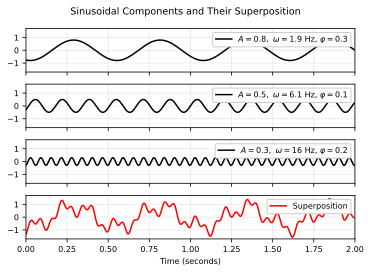

In [54]:
dur, sr = 2, 200
parameters = [
    (0.8, 1.9, 0.3),
    (0.5, 6.1, 0.1),
    (0.3, 16, 0.2),
]

components = [
    generate_sinusoid(dur=dur, amp=amp, freq=freq,
                      phase=phase, sr=sr)[0]
    for amp, freq, phase in parameters
]
x, t = generate_example_signal(dur=dur, sr=sr)

fig, axes = plt.subplots(
    4, 1, figsize=(5.2, 3.8), layout='tight',
    sharex=True, sharey=True,
)
fig.suptitle('Sinusoidal Components and Their Superposition')

for ax, signal, (amp, freq, phase) in zip(
        axes[:3], components, parameters):
    label = rf'$A={amp:g},\ \omega={freq:g}$ Hz, $\varphi={phase:g}$'
    ax.plot(t, signal, color='black', label=label)
    ax.legend(loc='upper right', framealpha=1)

axes[-1].plot(t, x, color='red', label='Superposition')
axes[-1].legend(loc='upper right', framealpha=1)

for ax in axes:
    ax.set(xlim=(0, dur), ylim=(-1.7, 1.7))
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (seconds)');

The first three plots show the individual sinusoids used to construct the signal. In the red superposition, these components are still present, but they are no longer easy to recognize by inspection. Before developing the mathematics, let us preview the central idea of **Fourier analysis**: we compare the sampled signal with suitable sinusoidal oscillations at many candidate frequencies between $0$ and $20$ Hz. Each comparison measures how strongly the signal agrees with one frequency. Plotting the resulting magnitudes against frequency produces a simple **spectrum**. Because the frequency components of this example are known, we mark them with red vertical lines. The following sections will explain the mathematics behind this procedure:

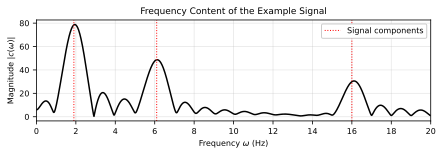

In [56]:
dur, sr = 1, 200
x, t = generate_example_signal(dur=dur, sr=sr)

freqs = np.linspace(0, 20, 1001)
magnitudes = np.zeros(len(freqs))

for k, freq in enumerate(freqs):
    e = np.exp(2j * np.pi * freq * t)
    magnitudes[k] = abs(np.vdot(e, x))

plt.figure(figsize=(6.2, 2.2), layout='tight')
plt.plot(freqs, magnitudes, color='black')

for k, freq in enumerate([1.9, 6.1, 16]):
    plt.axvline(
        freq, color='red', linestyle=':', linewidth=1,
        label='Signal components' if k == 0 else None,
    )

plt.title('Frequency Content of the Example Signal')
plt.xlabel(r'Frequency $\omega$ (Hz)')
plt.ylabel(r'Magnitude $|c(\omega)|$')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2))
plt.grid(alpha=0.3)
plt.legend(loc='upper right', framealpha=1);

The spectrum shows pronounced peaks near $1.9$, $6.1$, and $16$ Hz. Starting only from the superimposed waveform, the comparison has recovered the frequencies used to construct the signal. The largest peak occurs near $1.9$ Hz, reflecting the larger amplitude of this component. This is the change of perspective offered by Fourier analysis: the waveform organizes a signal over time, while its spectrum reveals the oscillations present at different frequencies. For now, the calculation may look like a useful numerical recipe. We next explain it step by step, beginning with the **inner product**, the mathematical tool underlying each comparison.

<a id="background_inner"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: The Geometric Meaning of Inner Products
</h2>

<div style="
  float:right;
  width:280px;
  max-width:48%;
  margin-left:20px;
  margin-bottom:10px;
  border:2px solid #1B5E20;
  padding:4px;
  background-color:white;
">
<img src="data/PCP_fig_inner_product.png"
     style="display:block; width:100%; height:auto;"
     alt="Geometric interpretation of inner products">
</div>

<p style="color:#1B5E20;">
Linear algebra allows us to treat a finite sequence of numbers as a vector. A vector with two or three coordinates can be drawn as an arrow. A signal with thousands of samples cannot, but the same geometric ideas still apply: it has a length, points in a direction, and can be compared with other vectors. Geometry therefore continues to work even when we can no longer draw the space. For real vectors $x,y\in\mathbb{R}^N$, the <strong>inner product</strong> is
$$
\langle x,y\rangle:=\sum_{n=0}^{N-1}x(n)y(n).
$$
The individual products reinforce or cancel one another, and their sum provides a single number describing the relationship between the vectors. The inner product determines the length, or <strong>norm</strong>, through $\|x\|:=\sqrt{\langle x,x\rangle}$. For nonzero vectors, it also determines their angle $\varphi$:
$$
\cos(\varphi)
=\frac{\langle x,y\rangle}{\|x\|\,\|y\|}.
$$
The normalized value is $1$ for the same direction, $-1$ for opposite directions, and $0$ for perpendicular directions. Perpendicular vectors are called <strong>orthogonal</strong>. Normalization matters because a large inner product may otherwise result simply from long vectors rather than similar directions.
</p>

<p style="color:#1B5E20;">
The complex numbers extend the real numbers, and the inner product can likewise be extended to complex vectors. This will be essential for Fourier analysis, where oscillations are represented by complex exponentials. For $x,y\in\mathbb{C}^N$, we use
$$
\langle x,y\rangle
:=\sum_{n=0}^{N-1}x(n)\overline{y(n)}.
$$
The conjugation ensures that $\langle x,x\rangle=\sum_{n=0}^{N-1}|x(n)|^2$ is real and nonnegative and can therefore still represent a squared length. Complex geometry is harder to visualize, but the main interpretation remains: the normalized magnitude $|\langle x,y\rangle|/(\|x\|\,\|y\|)$ lies between $0$ and $1$. Values near $1$ indicate strong alignment, while a value of $0$ means that the vectors are orthogonal and have no component in each other’s direction.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
The inner product also measures the <strong>component</strong> of one vector in a chosen direction. If $\|y\|=1$, the coefficient $\langle x,y\rangle$ describes how strongly $x$ is aligned with $y$. This interpretation remains valid when vectors represent audio signals, images, or other data rather than visible arrows. In Fourier analysis, the signal is the vector being examined, and the chosen directions are complex exponential vectors representing different frequencies. <strong>A Fourier coefficient measures the contribution of one such frequency direction to the signal.</strong>
</p>

<div style="clear:both;"></div>
</div>


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">
<p style="color:#E65100; margin:0;">
<strong>Convention matters:</strong> For real vectors, <code>np.dot(x, y)</code> computes the inner product directly, and the order does not matter because $\langle x,y\rangle=\langle y,x\rangle$. For complex vectors, <code>np.dot()</code> applies no complex conjugation and therefore does not compute the inner product defined above. Instead, we use <code>np.vdot()</code>. There is one detail to watch: <code>np.vdot(a, b)</code> conjugates its first argument, whereas our mathematical convention conjugates the second. Thus, $\langle x,y\rangle$ is computed as <code>np.vdot(y, x)</code>. Complex inner products are <strong>conjugate symmetric</strong>, meaning that $\langle x,y\rangle=\overline{\langle y,x\rangle}$. Swapping the arguments therefore preserves the magnitude but reverses the sign of the phase, which matters when interpreting complex Fourier coefficients.
</p>
</div>

<a id="signal_inner"></a>

## Comparing Signals with Inner Products

The previous <a href="#background_inner">background box</a> interpreted the inner product geometrically. We now apply it to finite signals. A signal consisting of $N$ samples can be represented as a vector

$$
x=\bigl(x(0),x(1),\ldots,x(N-1)\bigr)^\top\in\mathbb{R}^N,
$$

where $n=0,\ldots,N-1$ is the sample index. For two real-valued signals $x,y\in\mathbb{R}^N$, their inner product is

$$
\langle x,y\rangle
:=\sum_{n=0}^{N-1}x(n)y(n).
$$

This calculation compares the signals sample by sample. If both values are positive or both are negative, their product contributes positively. If they have opposite signs, it contributes negatively. Summing over all $N$ samples collects these agreements and disagreements into a single number. Signals that are similarly aligned tend to have a positive inner product, oppositely aligned signals tend to have a negative one, and orthogonal signals have inner product zero. This idea is closely related to **correlation**, which measures how well two signals align. More generally, correlation compares one signal with shifted versions of another. Here, no shift is applied, so the inner product may be regarded as their correlation at zero shift.

The result reflects both alignment and magnitude. Increasing the amplitude of either signal also increases the inner product, even when its shape remains unchanged. It is therefore an unnormalized measure of agreement rather than a comparison of shape alone. Its sign still carries useful information by distinguishing similar from opposite alignment. In the following example, we use the first second of our running signal at the sampling rate $F_{\mathrm{s}}=64$ Hz. The resulting vector $x\in\mathbb{R}^{64}$ contains $N=64$ samples indexed by $n=0,\ldots,63$. We compare $x$ with itself and with two unit-amplitude sinusoids, $y_1$ and $y_2$, at $2$ Hz and $6$ Hz. Their phases are selected to align well with nearby components of $x$. Finally, we compare the two sinusoids with each other. Each plot shows the signals over their sample indices and the corresponding real inner product:


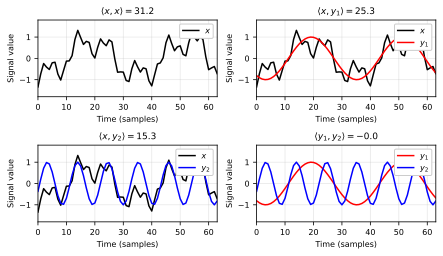

In [58]:
sr, dur = 64, 1
x, _ = generate_example_signal(dur=dur, sr=sr)
y1, _, _ = generate_sinusoid(dur=dur, freq=2, phase=0.35, sr=sr)
y2, _, _ = generate_sinusoid(dur=dur, freq=6, phase=0.06, sr=sr)

N = len(x)
n = np.arange(N)


def plot_inner_product_real(ax, n, x, y, label_x, label_y,
                            color_x='black', color_y='red'):
    """Plot two real signals and their inner product."""
    ax.plot(n, x, color=color_x, label=rf'${label_x}$')
    if y is not x:
        ax.plot(n, y, color=color_y, label=rf'${label_y}$')

    value = np.dot(x, y)
    ax.set(
        xlim=(n[0], n[-1]), ylim=(-1.8, 1.8),
        xlabel='Time (samples)', ylabel='Signal value',
        title=rf'$\langle {label_x},{label_y}\rangle={value:.1f}$',
    )
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', framealpha=1)


comparisons = [
    (x,  x,  'x',   'x',   'black', 'black'),
    (x,  y1, 'x',   'y_1', 'black', 'red'),
    (x,  y2, 'x',   'y_2', 'black', 'blue'),
    (y1, y2, 'y_1', 'y_2', 'red',   'blue'),
]

fig, axes = plt.subplots(2, 2, figsize=(6.2, 3.6), layout='tight')

for ax, (u, v, label_u, label_v, color_u, color_v) in zip(
        axes.flat, comparisons):
    plot_inner_product_real(
        ax, n, u, v, label_u, label_v,
        color_x=color_u, color_y=color_v,
    )

The figure illustrates how the inner product summarizes agreement between finite signals:

* Comparing $x$ with itself gives $\langle x,x\rangle=31.2$. This value equals $\lVert x\rVert^2$ and may be interpreted as the energy of the finite signal.
* The broad oscillations of $x$ align well with the $2$ Hz sinusoid $y_1$, producing the relatively large value $\langle x,y_1\rangle=25.3$.
* The finer oscillations captured by the $6$ Hz sinusoid $y_2$ produce the smaller but still noticeable value $\langle x,y_2\rangle=15.3$.
* The two sinusoids complete different integer numbers of cycles over the one-second interval. Their positive and negative products cancel, giving $\langle y_1,y_2\rangle\approx0$. They are therefore orthogonal over these $N=64$ samples.

These comparisons reveal prominent components near $2$ Hz and $6$ Hz in $x$. This is already the central idea of **Fourier analysis**: compare a finite signal with oscillations of different frequencies and use the resulting inner products to measure how strongly each frequency is represented. However, we selected the phases of $y_1$ and $y_2$ carefully. We next examine why phase matters and how an unsuitable phase can hide an oscillation that is present in the signal.

<a id="signal_phase"></a>
## The Role of Phase

In the preceding example, the phases of $y_1$ and $y_2$ were chosen to align well with corresponding oscillations in $x$. This choice matters: even when two signals have the same frequency, their inner product may be small because their oscillations are shifted relative to each other. To examine this effect, consider the family of finite sampled sinusoids

$$
g_{\omega,\varphi}(n)
:=\sin\left(2\pi\left(
\omega\frac{n}{F_{\mathrm{s}}}-\varphi
\right)\right),
\qquad n=0,\ldots,N-1.
$$

The frequency $\omega$ determines how rapidly the sinusoid oscillates, while the phase $\varphi\in[0,1)$ determines its position within one cycle. The difference between the phases of two sinusoids is called a **phase shift**.

We retain $N=64$ and $F_{\mathrm{s}}=64$ Hz, fix the frequency at $\omega=2$ Hz, and vary only the phase. The following figure begins with the well-aligned phase $\varphi=0.35$ and then shifts the sinusoid in successive quarter-cycle steps. Initially, the inner product is large and positive. After a quarter-cycle shift, positive and negative contributions nearly cancel. A half-cycle shift reverses the sinusoid and produces a large negative value, while the final quarter-cycle shift again gives a value close to zero. All four comparison signals have the same frequency and amplitude; only their phases differ:

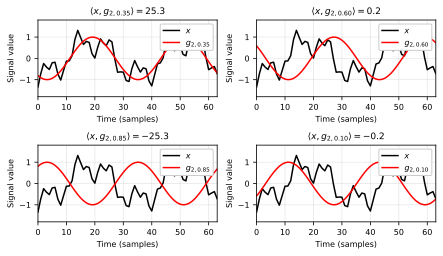

In [59]:
freq, phase_start = 2, 0.35
phases = (phase_start + 0.25 * np.arange(4)) % 1

fig, axes = plt.subplots(2, 2, figsize=(6.2, 3.6), layout='tight')

for ax, phase in zip(axes.flat, phases):
    g, _, _ = generate_sinusoid(
        dur=dur, freq=freq, phase=phase, sr=sr
    )
    label = rf'g_{{{freq},{phase:.2f}}}'
    plot_inner_product_real(ax, n, x, g, 'x', label)

<a id="complex_exponentials"></a>

## Comparing Signals with Complex Exponentials

The preceding section revealed a difficulty: the inner product with a real sinusoid depends strongly on its phase. Testing every possible phase would require many separate comparisons. A complex exponential solves this problem more efficiently by combining a cosine and a sine of the same frequency. Since these oscillations differ by a quarter cycle, together they account for every possible phase. For a frequency $\omega$, define the complex-valued vector

$$
e_\omega(n)
:=\exp\left(2\pi i\omega\frac{n}{F_{\mathrm{s}}}\right),
\qquad n=0,\ldots,N-1.
$$

Using <a href="PCP_07_exp.html#euler">Euler's formula</a>, we obtain

$$
e_\omega(n)
=
\cos\left(2\pi\omega\frac{n}{F_{\mathrm{s}}}\right)
+i\sin\left(2\pi\omega\frac{n}{F_{\mathrm{s}}}\right).
$$

Thus, $\operatorname{Re}(e_\omega)$ is a cosine and $\operatorname{Im}(e_\omega)$ is a sine. Both are real-valued vectors in $\mathbb{R}^N$, while their combination $e_\omega$ belongs to $\mathbb{C}^N$.

Because $e_\omega$ is complex-valued, comparing it with a signal requires the complex inner product introduced in the <a href="#background_inner">background box</a>. The signal $x$ may belong to $\mathbb{R}^N$ or $\mathbb{C}^N$. Since every real-valued vector can also be regarded as a complex-valued one, the same complex inner product applies in both cases:

$$
c(\omega)
:=\langle x,e_\omega\rangle
=\sum_{n=0}^{N-1}x(n)\overline{e_\omega(n)}.
$$

For a real-valued signal $x\in\mathbb{R}^N$, this complex coefficient separates into two real comparisons:

$$
c(\omega)
=
\left\langle x,\operatorname{Re}(e_\omega)\right\rangle
-i\left\langle x,\operatorname{Im}(e_\omega)\right\rangle.
$$

The real part of $c(\omega)$ records the comparison with the cosine, while its negative imaginary part records the comparison with the sine. Together, they determine the real sinusoid of frequency $\omega$ that aligns most strongly with $x$:

* The magnitude $|c(\omega)|$ gives the strongest possible agreement with a unit-amplitude sinusoid of frequency $\omega$.
* The angle of $c(\omega)$ determines the phase at which this strongest agreement occurs.

With the phase convention used in this unit, the optimal cosine phase is

$$
\varphi_\omega
=-\frac{\arg(c(\omega))}{2\pi}
\pmod 1.
$$

Here, $\arg(c(\omega))$ is the angle of the complex coefficient in radians. Dividing by $2\pi$ converts this angle into cycles, while “modulo $1$” reflects that phases differing by one complete cycle describe the same sinusoid. The minus sign results from the complex conjugation in the inner product. Denoting the unit-amplitude cosine with frequency $\omega$ and optimal phase $\varphi_\omega$ by $\cos_{\omega,\mathrm{opt}}$, we obtain the central relationship

$$
|c(\omega)|
=\left\langle x,\cos_{\omega,\mathrm{opt}}\right\rangle.
$$

In other words, two fixed comparisons, one with a cosine and one with a sine, replace a search through all possible phases. The angle of $c(\omega)$ identifies the optimal phase, while its magnitude equals the agreement obtained at that phase.

This **optimal-phase property** applies directly to real-valued signals $x\in\mathbb{R}^N$. For a general complex-valued signal $x\in\mathbb{C}^N$, the coefficient $c(\omega)$ still measures agreement with the complex frequency vector $e_\omega$, but it does not reduce to a comparison with a single real sinusoid. The optimal-phase result is important but not immediately obvious; it follows from Euler's formula and the angle-difference identities for sine and cosine. A complete derivation and a broader treatment of Fourier analysis can be found in Chapter 2 of the textbook <a href="https://www.audiolabs-erlangen.de/fau/professor/mueller/bookFMP">Fundamentals of Music Processing</a>.

The following figures make the relationship visible for our real-valued running signal and the frequency $\omega=2$ Hz. The first shows $x$ together with the cosine and sine contained in $e_2$. The second shows the optimally phased cosine determined by $c(2)$. Its inner product with $x$ equals the magnitude $|c(2)|$:

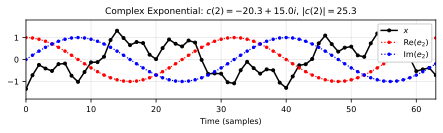

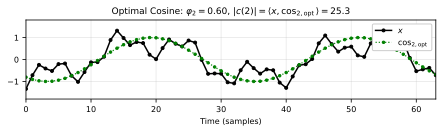

In [73]:
sr, freq = 64, 2
x, _ = generate_example_signal(dur=1, sr=sr)


def plot_frequency_comparison(ax, x, freq, sr, show_optimal=False):
    """Compare a signal with a complex exponential or optimal cosine."""
    N = len(x)
    n = np.arange(N)
    e = np.exp(2j * np.pi * freq * n / sr)
    c = np.vdot(e, x)

    ax.plot(n, x, 'ko-', ms=3, lw=1.5, label='$x$')

    if show_optimal:
        phase = (-np.angle(c) / (2 * np.pi)) % 1
        cos_opt = np.cos(2 * np.pi * (freq * n / sr - phase))
        value = np.dot(x, cos_opt)
        ax.plot(n, cos_opt, 'g:o', ms=2.5, lw=1.2,
                label=rf'$\cos_{{{freq},\mathrm{{opt}}}}$')
        title = (
            rf'Optimal Cosine: $\varphi_{{{freq}}}={phase:.2f}$, '
            rf'$|c({freq})|=\langle x,\cos_{{{freq},\mathrm{{opt}}}}\rangle'
            rf'={value:.1f}$'
        )
    else:
        ax.plot(n, e.real, 'r:o', ms=2.5, lw=1.2,
                label=rf'$\operatorname{{Re}}(e_{{{freq}}})$')
        ax.plot(n, e.imag, 'b:o', ms=2.5, lw=1.2,
                label=rf'$\operatorname{{Im}}(e_{{{freq}}})$')
        title = (
            rf'Complex Exponential: $c({freq})={c.real:.1f}{c.imag:+.1f}i$, '
            rf'$|c({freq})|={abs(c):.1f}$'
        )

    ax.set(xlim=(0, N - 1), ylim=(-1.8, 1.8),
           xlabel='Time (samples)', title=title)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', framealpha=1)


for show_optimal in [False, True]:
    fig, ax = plt.subplots(figsize=(6.2, 1.9), layout='tight')
    plot_frequency_comparison(ax, x, freq, sr, show_optimal)

<a id="dft"></a>

## Discrete Fourier Transform (DFT)

In the introductory example, we compared the signal with sinusoidal oscillations at many candidate frequencies between $0$ and $20$ Hz. In principle, we could evaluate this comparison on an increasingly fine frequency grid, but we could never consider every real-valued frequency. Such a calculation would be computationally impossible and unnecessarily redundant: a signal with only $N$ samples has just $N$ independent values, so $N$ suitably chosen frequency coefficients are enough to describe it completely.

But which $N$ frequencies should we choose? The **discrete Fourier transform (DFT)** makes a practical and mathematically natural choice. For a signal $x\in\mathbb{R}^N$ sampled at the rate $F_{\mathrm{s}}$, it selects oscillations whose phases advance by an integer number of complete cycles over $N$ sampling steps. Their frequencies are

$$
\omega_k:=\frac{kF_{\mathrm{s}}}{N},
\qquad k=0,\ldots,N-1.
$$

Here, $k$ is the **frequency index**, and $\omega_k$ is the corresponding frequency in hertz. Neighboring frequencies are separated by the constant distance

$$
\Delta\omega:=\frac{F_{\mathrm{s}}}{N},
$$

called the **frequency-bin spacing** or **frequency resolution**. This formula connects the frequency grid directly to the observed time interval. The $N$ samples cover $N/F_{\mathrm{s}}$ seconds, so observing a signal for longer at the same sampling rate produces more samples and finer frequency spacing.

For our running example, $N=64$ and $F_{\mathrm{s}}=64$ Hertz. The signal covers one second, and the frequency spacing is $\Delta\omega=1$ Hertz. Thus, $\omega_k=k$ Hertz: in this special case, the frequency index $k$ directly gives the frequency in Hertz. More generally, the complex oscillations selected above have a remarkably regular structure and are **mutually orthogonal** over the $N$ sample positions. As we will see, this allows every finite signal to be represented by exactly $N$ frequency coefficients and **reconstructed without loss**. The same symmetry also provides the structure exploited by the fast Fourier transform. The following figure makes the frequency grid visible in the time domain. It shows the real and imaginary parts of four selected oscillations. The frequency index $k$ specifies how many complete cycles each oscillation performs over $N$ sampling steps:

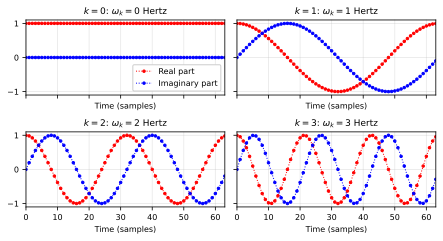

In [77]:
N = sr = 64
n = np.arange(N)
indices = [0, 1, 2, 3]

fig, axes = plt.subplots(
    2, 2, figsize=(6.2, 3.4), layout='tight',
    sharex=True, sharey=True,
)

for ax, k in zip(axes.flat, indices):
    freq = k * sr / N
    e = np.exp(2j * np.pi * k * n / N)

    ax.plot(n, e.real, 'r:o', ms=2.5, lw=1, label='Real part')
    ax.plot(n, e.imag, 'b:o', ms=2.5, lw=1, label='Imaginary part')
    ax.set(
        xlim=(0, N - 1), ylim=(-1.1, 1.1),
        xlabel='Time (samples)',
        title=rf'$k={k}$: $\omega_k={freq:g}$ Hertz',
    )
    ax.grid(alpha=0.3)

axes[0, 0].legend(loc='lower right', framealpha=1);

The DFT collects the comparisons with all $N$ selected frequency vectors into a single matrix, called the **DFT matrix**. This complex-valued matrix $\mathrm{DFT}_N\in\mathbb{C}^{N\times N}$ is defined by

$$
\mathrm{DFT}_N(k,n)
:=\exp\left(-2\pi i\frac{kn}{N}\right),
\qquad k,n=0,\ldots,N-1.
$$

For a real-valued signal $x\in\mathbb{R}^N$, its DFT is the complex-valued vector $X\in\mathbb{C}^N$ obtained through the matrix–vector product

$$
X:=\mathrm{DFT}_N\cdot x.
$$

The DFT coefficient at frequency index $k$ is therefore

$$
X(k)
=\sum_{n=0}^{N-1}x(n)
\exp\left(-2\pi i\frac{kn}{N}\right)
=\langle x,e_k\rangle.
$$

Thus, the $k^\mathrm{th}$ row of $\mathrm{DFT}_N$ contains the transposed conjugate frequency vector $\overline{e_k}^{\top}$. Each row compares $x$ with one frequency, and together the $N$ rows produce the complete frequency representation $X$. The structure of the matrix becomes especially clear when expressed using the <a href="PCP_07_exp.html#roots">roots of unity</a>. Let

$$
\rho_N:=\exp\left(\frac{2\pi i}{N}\right),
\qquad
\sigma_N:=\overline{\rho_N}
=\exp\left(-\frac{2\pi i}{N}\right).
$$

Both are primitive $N^\mathrm{th}$ roots of unity. The value $\rho_N$ represents one counterclockwise angular step of $2\pi/N$ around the unit circle, while $\sigma_N$ represents the corresponding clockwise step. Since

$$
\sigma_N^{kn}
=\exp\left(-2\pi i\frac{kn}{N}\right),
$$

the DFT matrix consists entirely of powers of $\sigma_N$:

$$
\mathrm{DFT}_N
=
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1\\
1 & \sigma_N & \sigma_N^2 & \cdots & \sigma_N^{N-1}\\
1 & \sigma_N^2 & \sigma_N^4 & \cdots & \sigma_N^{2(N-1)}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & \sigma_N^{N-1} & \sigma_N^{2(N-1)}
& \cdots & \sigma_N^{(N-1)(N-1)}
\end{pmatrix}.
$$

Each row of $\mathrm{DFT}_N$ represents one frequency index $k$, while each column corresponds to one sample index $n$. The matrix entries have modulus $1$, but their real and imaginary parts vary between $-1$ and $1$ as the powers of $\sigma_N$ rotate around the unit circle. In the following visualization, red represents positive values, blue represents negative values, and white represents values near zero. The resulting repetitions, reflections, and oscillatory patterns reveal the highly regular structure of the DFT matrix:

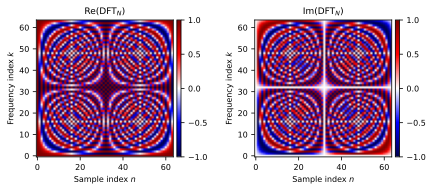

In [90]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def generate_matrix_dft(N):
    """Generate the N x N DFT matrix."""
    n = np.arange(N)
    return np.exp(-2j * np.pi * n[:, None] * n / N)


N = 64
dft = generate_matrix_dft(N)
fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.7), layout='tight')

for ax, values, part in zip(
        axes, [dft.real, dft.imag], ['Re', 'Im']):
    image = ax.imshow(values, origin='lower', cmap='seismic',
                      vmin=-1, vmax=1, aspect='equal')
    ax.set(title=rf'$\operatorname{{{part}}}(\mathrm{{DFT}}_N)$',
           xlabel='Sample index $n$', ylabel='Frequency index $k$')

    cax = make_axes_locatable(ax).append_axes('right', size='3%', pad=0.05)
    fig.colorbar(image, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])

We have seen that the DFT transforms a time-domain signal $x\in\mathbb{R}^N$ into a frequency-domain vector $X\in\mathbb{C}^N$ through the matrix–vector product $X=\mathrm{DFT}_N\cdot x$. The vector $X$ contains one complex coefficient $X(k)$ for each frequency index $k$. Its magnitude $|X(k)|$ indicates the strength of the corresponding frequency, while its angle contains phase information.

Interpreting the frequency indices requires some care. Because of sampling, frequencies that differ by an integer multiple of the sampling rate produce the same samples. This is the frequency-domain version of the **aliasing phenomenon** discussed in <a href="PCP_08_signal.html#aliasing">Unit 8</a>. Consequently, indices above $N/2$ do not describe genuinely new high-frequency oscillations. Their samples agree with lower-frequency oscillations rotating in the opposite direction, so they are interpreted as **negative frequencies**. More precisely, the frequency associated with index $N-k$ differs from $-kF_{\mathrm{s}}/N$ by exactly one sampling rate:

$$
\frac{(N-k)F_{\mathrm{s}}}{N}
=
F_{\mathrm{s}}-\frac{kF_{\mathrm{s}}}{N}
\quad\longleftrightarrow\quad
-\frac{kF_{\mathrm{s}}}{N}.
$$

The arrow indicates that the two frequencies produce the same sampled oscillation. For example, when $N=F_{\mathrm{s}}=64$, index $62$ may formally suggest $62$ Hertz, but it equivalently represents $62-64=-2$ Hertz. Similarly, indices $58$ and $48$ represent $-6$ and $-16$ Hertz. For even $N$, the indices $0,\ldots,N/2$ cover the nonnegative frequencies up to the Nyquist frequency, while the remaining indices represent negative frequencies.

For a real-valued signal, the positive- and negative-frequency coefficients are closely related. They satisfy the **conjugate-symmetry** property

$$
X(N-k)=\overline{X(k)},
\qquad
|X(N-k)|=|X(k)|,
\qquad k=1,\ldots,N-1.
$$

The magnitudes at opposite frequencies are therefore equal. This symmetry has an intuitive explanation: a real sinusoid can be formed by combining two complex oscillations that rotate at the same rate in opposite directions. When the DFT coefficients are arranged from negative to positive frequencies, the magnitude spectrum of a real signal consequently appears symmetric around $0$ Hertz.

The following implementation constructs the DFT matrix and applies it using the Python matrix-multiplication operator `@`. The first figure shows the signal and its DFT coefficients in their original storage order, with frequency indices $k=0,\ldots,N-1$. The second figure uses `np.fft.fftshift()` to reorder the same coefficients from negative to positive frequency indices. Both figures retain the discrete representation: the signal is displayed over sample indices $n$, and its spectrum over frequency indices $k$:

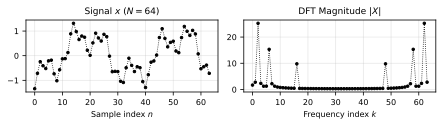

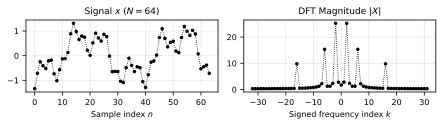

In [104]:
def dft(x):
    """Compute the discrete Fourier transform."""
    return generate_matrix_dft(len(x)) @ x


def plot_signal_dft(x, X, sr, axes='indices'):
    """Plot a signal and its DFT using different coordinate systems."""
    N = len(x)
    n = np.arange(N)
    k = np.arange(N)
    k_signed = np.arange(-(N // 2), (N + 1) // 2)

    if axes == 'indices':
        time, freq, magnitude = n, k, np.abs(X)
        xlabel_time = 'Sample index $n$'
        xlabel_freq = 'Frequency index $k$'
    elif axes == 'signed':
        time, freq = n, k_signed
        magnitude = np.fft.fftshift(np.abs(X))
        xlabel_time = 'Sample index $n$'
        xlabel_freq = 'Signed frequency index $k$'
    elif axes == 'physical':
        time, freq = n / sr, k_signed * sr / N
        magnitude = np.fft.fftshift(np.abs(X))
        xlabel_time = 'Time (seconds)'
        xlabel_freq = 'Frequency (Hertz)'
    else:
        raise ValueError("axes must be 'indices', 'signed', or 'physical'")

    fig, ax = plt.subplots(1, 2, figsize=(6.2, 1.8), layout='tight')
    ax[0].plot(time, x, 'k:o', ms=2.5, lw=0.8)
    ax[1].plot(freq, magnitude, 'k:o', ms=2.5, lw=0.8)

    ax[0].set(title=rf'Signal $x$ ($N={N}$)', xlabel=xlabel_time)
    ax[1].set(title=r'DFT Magnitude $|X|$', xlabel=xlabel_freq)

    for a in ax:
        a.grid(alpha=0.3)


sr = 64
x, _ = generate_example_signal(dur=1, sr=sr)
X = dft(x)

plot_signal_dft(x, X, sr, axes='indices')
plot_signal_dft(x, X, sr, axes='signed')


The first two figures use the natural coordinates of finite vectors: $n$ identifies a sample, and $k$ identifies a frequency coefficient. To connect these indices with physical time and frequency, we use the sampling rate $F_{\mathrm{s}}$. Sample index $n$ corresponds to the time

$$
t_n=\frac{n}{F_{\mathrm{s}}},
$$

while signed frequency index $k$ corresponds to

$$
\omega_k=\frac{kF_{\mathrm{s}}}{N}
=k\,\Delta\omega.
$$

This conversion does not change the signal or its DFT; it only rescales the axes into seconds and Hertz. For our example, $N=F_{\mathrm{s}}=64$, so one sample step corresponds to $1/64$ second and one frequency step corresponds to $1$ Hertz. The following figure displays the same data using these physical units:

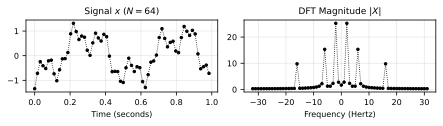

In [105]:
plot_signal_dft(x, X, sr, axes='physical')

The physical frequency axis reveals prominent contributions near $\pm2$, $\pm6$, and $\pm16$ Hertz. The spectrum is symmetric because $x$ is real-valued: every positive-frequency component has a corresponding negative-frequency component of equal magnitude. The component at $16$ Hertz lies exactly on the DFT grid, while $1.9$ and $6.1$ Hertz lie between neighboring grid points and spread across several coefficients. This phenomenon is called **spectral leakage** and will be explored in <a href="#exercise_leakage">Exercise 1</a>. The DFT is also invertible, meaning that the original signal can be reconstructed from its complex coefficients without loss. The inverse DFT and the modification of frequency coefficients will be investigated in <a href="#exercise_spectral_modification">Exercise 3</a>.

<a id="background_complexity"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Computational Efficiency and the Power of Algorithms
</h2>

<p style="color:#1B5E20;">
The time required by a program depends on the computer, the programming language, and the implementation. More fundamentally, however, it depends on the <strong>algorithm</strong>: the strategy used to organize the computation. A clever algorithm can eliminate enormous amounts of unnecessary work. This improvement is often far more important than optimizing individual instructions or purchasing faster hardware.
</p>

<p style="color:#1B5E20;">
To describe how computational work grows with the input size $N$, computer science uses <strong>asymptotic notation</strong>, commonly called <strong>big-O notation</strong>. An algorithm of complexity $\mathcal{O}(N)$ grows approximately linearly, while an $\mathcal{O}(N^2)$ algorithm grows quadratically. Doubling $N$ therefore roughly doubles the work in the first case but quadruples it in the second. An algorithm with complexity $\mathcal{O}(N\log_2N)$ lies between these two behaviors and remains practical for much larger inputs.
</p>

<p style="color:#1B5E20;">
This distinction becomes dramatic for long signals. For $N=65\,536=2^{16}$ samples, the quantities that characterize quadratic and nearly linear growth are
$$
N^2\approx4.3\cdot10^9,
\qquad
N\log_2N\approx1.0\cdot10^6.
$$
These are not exact operation counts, but they reveal the difference in scale: billions of computational steps versus roughly a million. Faster hardware may improve both calculations by a constant factor, whereas the better algorithm changes how rapidly the required work grows.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
A direct evaluation of the DFT requires $\mathcal{O}(N^2)$ operations. The <strong>fast Fourier transform (FFT)</strong> computes exactly the same coefficients in only $\mathcal{O}(N\log_2N)$ operations by exploiting symmetries among the complex oscillations. This breakthrough made large-scale Fourier analysis practical and helped transform fields ranging from telecommunications and digital audio to medical imaging, radar, astronomy, and scientific computing. The FFT is therefore more than a faster implementation of the DFT: it is a striking example of how a clever algorithm can change entire industries.
</p>

</div>


<a id='fft'></a>
## Fast Fourier Transform (FFT)

The DFT matrix gives us a clear mathematical definition and a direct Python implementation. However, constructing an $N\times N$ matrix and multiplying it by a vector requires a large number of operations when $N$ becomes large. A direct DFT requires approximately $N^2$ arithmetic operations, so doubling the signal length increases the computational work by roughly a factor of four.

The **fast Fourier transform (FFT)** computes exactly the same DFT coefficients without explicitly constructing the full matrix. By exploiting the symmetry of the roots of unity, it reduces the computational cost from order $N^2$ to order $N\log_2N$. This improvement is dramatic for long signals and makes Fourier analysis practical for applications involving audio, images, video, and large scientific datasets.

<a id='fft'></a>
## Fast Fourier Transform (FFT)

Next, we discuss the famous fast Fourier transform (FFT), which is a fast algorithm to compute the DFT. The FFT algorithm was originally found by Gauss in about 1805 and  then rediscovered by Cooley and Tukey in 1965. The FFT algorithm is based on the observation that applying a DFT of even size $N=2M$ can be expressed in terms of  applying two DFTs of half the size $M$. It exploits the fact that there are algebraic relations between the entries $\sigma_N^{kn} = \mathrm{exp}(-2 \pi i / N)^{kn}$ of DFT matrices. In particular, one has 

$$\sigma_M = \sigma_N^2$$

In the FFT algorithm, one computes the DFT of the even-indexed and the uneven-indexed entries of $x$:

\begin{align*}
(A(0), \dots, A(N/2-1)) &= \mathrm{DFT}_{N/2} \cdot (x(0), x(2), x(4), \dots, x(N-2))\\
(B(0), \dots, B(N/2-1)) &= \mathrm{DFT}_{N/2} \cdot (x(1), x(3), x(5), \dots, x(N-1))
\end{align*}

With these two DFTs of size $N/2$, one can compute the full DFT of size $N$ via:

\begin{eqnarray*}
C(k) &=& \sigma_N^k \cdot B(k)\\
X(k) &=& A(k) + C(k)\\
X(N/2 + k) &=& A(k) - C(k)\\
\end{eqnarray*}

for $k \in [0: N/2 - 1]$. The numbers $\sigma_N^k$ are also called *twiddle factors*. If $N$ is a power of two, this idea can be applied recursively until one reaches the computation of $\mathrm{DFT}_{1}$ (the case $N=1$), which is simply multiplication by one (i.e. just returning the signal of length $N=1$). For further details, we refer to Section 2.4.3 of <a href="http://www.music-processing.de">[Müller, FMP, Springer 2015])</a> (see also Table 2.1). 

In the following code, we provide a function `fft` that implements the FFT algorithm. We test the function  `fft` by comparing its output with the one when applying the `dft` on a test signal `x`. For the comparison of result matrices, we use the NumPy functions [`np.array_equal`](https://numpy.org/doc/stable/reference/generated/numpy.array_equal.html) and [`np.allclose`](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html#numpy.allclose).

In [ ]:
def fft(x):
    """Compute the fast Fourier transform (FFT)

    Notebook: PCP_09_dft.ipynb

    Args:
        x: Signal to be transformed

    Returns:
        X: Fourier transform of x
    """
    x = x.astype(np.complex128)
    N = len(x)
    log2N = np.log2(N)
    assert log2N == int(log2N), 'N must be a power of two!'
    X = np.zeros(N, dtype=np.complex128)

    if N == 1:
        return x
    else:
        this_range = np.arange(N)
        A = fft(x[this_range % 2 == 0])
        B = fft(x[this_range % 2 == 1])
        range_twiddle_k = np.arange(N // 2)
        sigma = np.exp(-2j * np.pi * range_twiddle_k / N)
        C = sigma * B
        X[:N//2] = A + C
        X[N//2:] = A - C
        return X
    
N = 64
x, t = generate_example_signal(Fs=N, dur=1)

X_via_dft = dft(x)
X_via_fft = fft(x)
X_via_fft_numpy = np.fft.fft(x)

is_equal = np.array_equal(X_via_dft, X_via_fft)
is_equal_tol = np.allclose(X_via_dft, X_via_fft)
is_equal_tol_np = np.allclose(X_via_dft, X_via_fft_numpy)

print('Equality test for dft(x) and fft(x) using np.array_equal:    ', is_equal)
print('Equality test for dft(x) and fft(x) using np.allclose:       ', is_equal_tol)
print('Equality test for dft(x) and np.fft.fft(x) using np.allclose:', 
      is_equal_tol_np)

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> The test shows that our <code>dft</code> and <code>fft</code> implementations do not yield the same result (due to numerical issues). However, the results are numerically very close, which is verified by the test using <code>np.allclose</code>.  
</div>

The FFT reduces the overall number of operations from the order of $N^2$ (needed when computing the usual matrix&ndash;vector product $\mathrm{DFT}_N \cdot x$) to the order of $N\log_2N$. The savings are enormous. For example, using $N=2^{10}=1024$, the FFT requires roughly $N\log_2N=10240$ instead of $N^2=1048576$ operations in the naive approach. Using the module `timeit`, which provides a simple way to time small bits of Python code, the following code compares the running time when using the naive approach and the FFT. Furthermore, we compare the running time with the highly optimized NumPy implementation <code>np.fft.fft</code>.

In [ ]:
rep = 3
for N in [256, 512, 1024, 2048, 4096]:
    time_index = np.arange(N)
    x = np.sin(2 * np.pi *  time_index / N )
    t_DFT = 1000 * timeit.timeit(lambda: dft(x), number=rep)/rep
    t_FFT = timeit.timeit(lambda: fft(x), number=rep*5)/(rep*5)
    t_FFT_np = timeit.timeit(lambda: np.fft.fft(x), number=rep*100)/(rep*100)
    print(f'Runtime (ms) for N = {N:4d} : DFT {t_DFT:10.2f},  '
          f'FFT {t_FFT:.5f},  FFT_np {t_FFT_np:.8f}')

<a id='exercise_freq_index'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 1: Interpretation of Frequency Indices</strong>
<p style="color:#006064;">
Given a dimension $N\in\mathbb{N}$, the $\mathrm{DFT}_N$ transform a vector $x\in\mathbb{C}^N$ into another vector $X\in\mathbb{C}^N$. Assuming that $x$ represents a time-domain signal sampled with a sampling rate $F_\mathrm{s}$, one can associate the index $n\in[0:N-1]$ of the sample $x(n)$ with the physical time point $t = n/F_\mathrm{s}$ given in seconds. In case of the vector $X$, the index $k\in[0:N-1]$ of the coefficient $X(k)$ can be associated to a physical frequency value 
$$
  \omega=\frac{k \cdot F_\mathrm{s}}{N}.
$$ 
Furthermore, using a real-valued signal $x\in\mathbb{R}^N$, the upper part of $X\in\mathbb{C}^N$ becomes redundant, and it suffices to consider the first $K$ coefficients with $K=N/2$.
</p>
<ul style="color:#006064;">
    <li>Find explanations why these properties apply.</li>
    <li>Find out how the function <code>plot_signal_dft</code> uses these properties to convert and visualize the time and frequency axes.</li>   
    <li>Using the signal <code>x, t = generate_example_signal(Fs=64, dur=2)</code>, plot the signal and its magnitude Fourier transform once using axes given in indices and once using axes given in physical units (seconds, Hertz). Discuss the results.</li>
    <li>Do the same for the signal <code>x, t = generate_example_signal(Fs=32, dur=2)</code>. What is going wrong and why?</li>  
</ul>
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_freq_index() 

<a id='exercise_missing_time'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 2: Missing Time Localization</strong>
<p style="color:#006064;">
The Fourier transform yields frequency information that is averaged over the entire time axis. However, the information on when these frequencies occur is hidden in the transform. To demonstrate this phenomenon, construct the following two different signals defined on a common time axis $[0, T]$ with $T$ given in seconds (e.g., $T=6~\mathrm{sec}$). 
</p>
    
<ul style="color:#006064;">
    <li>A superposition of two sinusoids $f_1+f_2$ defined over the entire time interval $[0, T]$, where the first sinusoid $f_1$ has a frequency $\omega_1=1~\mathrm{Hz}$ and an amplitude of $1$, while the second sinusoid $f_2$ has a frequency $\omega_2=5~\mathrm{Hz}$ and an amplitude of $0.5$.</li>
    <li>A concatenation of two sinusoids, where $f_1$ (specified as before) is now defined only on the subinterval $[0, T/2]$, and $f_2$ is defined on the subinterval $[T/2, T]$.
</ul>

<p style="color:#006064;">
Sample the interval $[0,T]$ to obtain $N$ samples (use <code>np.linspace</code>), with $N\in\mathbb{N}$ being power of two (e.g., $N=256$). Define DT-signals of the superposition and the concatenation and compute the DFT for each of the signals. Plot the signals as well as the resulting magnitude Fourier transforms and discuss the result.
</p>
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_missing_time() 

<a id='exercise_chirp'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 3: Chirp Signal</strong>
<p style="color:#006064;">
The function $f(t)=\sin\left(\pi t^2\right)$ defines a <strong>chirp signal</strong> (also called <strong>sweep signal</strong>), in which the frequency increases with time. The <strong>instantaneous frequency $\omega_t$</strong> of the chirp signal at time $t$ is the derivate of the sinusoid's argument divided by $2\pi$, thus $\omega_t = t$. 
</p>
<ul style="color:#006064;">
    <li>Let $[t_0,t_1]$ be a time interval (given in seconds) with $0\leq t_0<t_1$ and $N\in\mathbb{N}$ be power of two. Implement a function <code>generate_chirp</code> that outputs a sampled chirp signal <code>x</code> over the interval $[t_0,t_1]$ with $N$ samples (use <code>np.linspace</code>).</li>
    <li>Compute the DFT of <code>x</code> for various input parameters $t_0$, $t_1$, and $N$. Plot the chirp signal as well as the resulting magnitude Fourier transform. Discuss the result.</li>
</ul>    
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_chirp() 

<a id='exercise_inverse'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 4: Inverse DFT</strong>
<p style="color:#006064;">
The discrete Fourier transform given by the matrix $\mathrm{DFT}_N \in \mathbb{C}^{N\times N}$ is an invertible operation, given by the inverse DFT matrix $\mathrm{DFT}_N^{-1}$. 
</p>
<ul style="color:#006064;">
    <li>There is an explicit relation between $\mathrm{DFT}_N$ and its inverse $\mathrm{DFT}_N^{-1}$. Which one? </li>
    <li>Write a function <code>generate_matrix_dft_inv</code> that explicitly generates $\mathrm{DFT}_N^{-1}$. 
    <li>Check your function by computing $\mathrm{DFT}_N \cdot \mathrm{DFT}_N^{-1}$ and $\mathrm{DFT}_N^{-1} \cdot \mathrm{DFT}_N$ (using <code>np.matmul</code>) and comparing these products with the identity matrix (using <code>np.eye</code> and <code>np.allclose</code>).</li>
    <li>Furthermore, compute the inverse DFT by using <code>np.linalg.inv</code>. Compare the result with your function using <code>np.allclose</code>.
    <li>Similar to <code>fft</code>, implement a fast inverse Fourier transform <code>fft_inv</code></li>    
</ul>    
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_inverse()  

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>